# Risk Score Analysis & Empirical Consistency Check

<br><br>

## 0. Imports

In [133]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from utils import load_fire_df, load_risk_df

<br><br>

## 1. Setup & Data

In [134]:
fire = load_fire_df()[['h3_id', 'hour_bin']].drop_duplicates().copy()
risk = load_risk_df()[['h3_id', 'hour_bin', 'risk', 'dist_fire']].copy()

In [135]:
# Define risk bins
bin_size = 0.1
bin_edges = np.round(np.arange(0.0, 1.0 + bin_size, bin_size), 10)
bin_labels = [f'[{bin_edges[i]:.1f}, {bin_edges[i+1]})' for i in range(len(bin_edges) - 1)]

In [136]:
# Define window sizes
w_values = [24, 48, 72]

In [137]:
# Helper function to mark if cells are active within next w hours
def add_future_fire_label(risk: pd.DataFrame, fire: pd.DataFrame, w: int) -> pd.DataFrame:
    # Build (h3_id, t) where fire occurs between t and t + w
    offsets = pd.to_timedelta(np.arange(1, w + 1), unit = 'h')
    offsets_df = pd.DataFrame({'offset': offsets, 'key': 1})

    future_hits = (
        fire.assign(key = 1)
        .merge(offsets_df, on = 'key', how = 'inner')
        .drop(columns = 'key')
    )

    future_hits['hour_bin'] = future_hits['hour_bin'] - future_hits['offset']
    future_hits = future_hits[['h3_id', 'hour_bin']].drop_duplicates()
    future_hits['future_fire'] = 1

    # Censor training period where w can't be observed
    max_fire_time = fire['hour_bin'].max()
    valid_risk = risk[risk['hour_bin'] <= (max_fire_time - pd.Timedelta(hours = w))].copy()

    labeled = valid_risk.merge(future_hits, on = ['h3_id', 'hour_bin'], how = 'left')
    labeled['future_fire'] = labeled['future_fire'].fillna(0).astype(int)
    return labeled

# Function to get fire proportions
def get_fire_proportions(risk: pd.DataFrame, fire: pd.DataFrame) -> pd.DataFrame:
    # Compute tables
    rows = []

    for w in w_values:
        df_h = add_future_fire_label(risk, fire, w)

        df_h['risk_bin'] = pd.cut(
            df_h['risk'],
            bins = bin_edges,
            labels = bin_labels,
            include_lowest = True,
            right = False
        )
        df_h = df_h.dropna(subset = ['risk_bin']).copy()

        summary = (
            df_h.groupby('risk_bin', observed = True)
            .agg(
                n = ('future_fire', 'size'),
                n_future_fire = ('future_fire', 'sum'),
                rate = ('future_fire', 'mean'),
                risk_mean = ('risk', 'mean')
            )
            .reset_index()
        )

        baseline = df_h['future_fire'].mean()
        summary['baseline_rate'] = baseline
        summary['lift_vs_baseline'] = np.where(baseline > 0, summary['rate'] / baseline, np.nan)
        summary['horizon_h'] = w

        rows.append(summary)

    return pd.concat(rows, ignore_index = True)

# Helper function to compute summary table
def get_pivot_table(results: pd.DataFrame) -> pd.DataFrame:
    return results.pivot_table(
        index = 'risk_bin',
        columns = 'horizon_h',
        values = 'rate'
    ).sort_index()

<br><br>

## 2. Fire Onset Probabilities

In [138]:
proportions = get_fire_proportions(risk, fire)
proportions_table = get_pivot_table(proportions)
proportions_table

/var/folders/w1/ftfbr5xs18x1zlwfq09kkxgm0000gn/T/ipykernel_62175/78696389.py:64: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  return results.pivot_table(


horizon_h,24,48,72
risk_bin,,,
"[0.0, 0.1)",0.000995,0.002360,0.004419
"[0.1, 0.2)",0.018369,0.040318,0.052464
"[0.2, 0.3)",0.103411,0.177174,0.209935
"[0.3, 0.4)",0.271755,0.368556,0.401984
"[0.4, 0.5)",0.280055,0.376719,0.424840
"[0.5, 0.6)",0.457143,0.537452,0.538996
"[0.6, 0.7)",0.698451,0.719309,0.721097
"[0.7, 0.8)",0.643089,0.653252,0.655285
"[0.8, 0.9)",0.639191,0.688958,0.706065


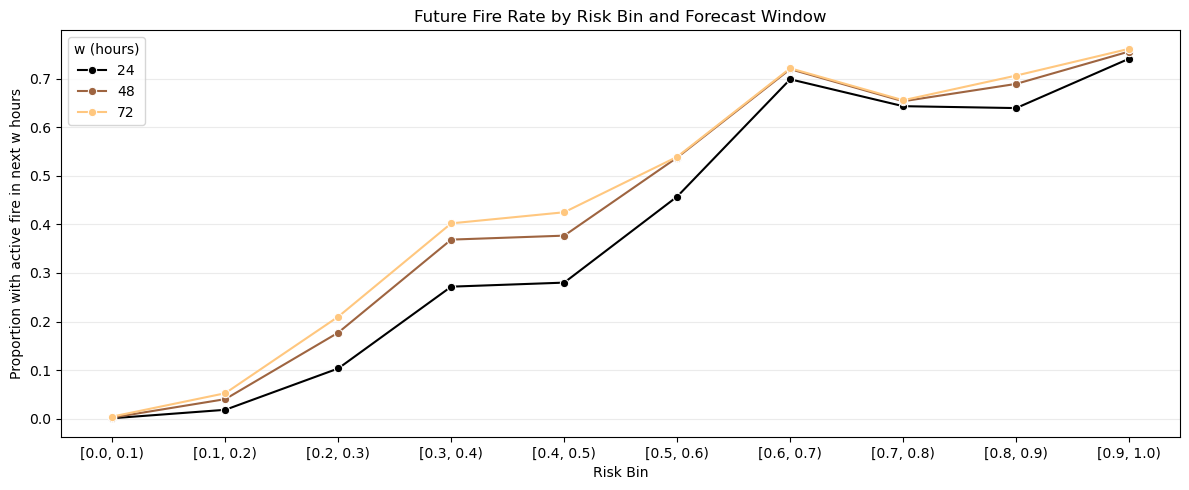

In [139]:
# Plot
plt.figure(figsize = (12, 5))
sns.lineplot(
    data = proportions,
    x = 'risk_bin',
    y = 'rate',
    hue = 'horizon_h',
    marker = 'o',
    palette = 'copper'
)
plt.xlabel('Risk Bin')
plt.ylabel('Proportion with active fire in next w hours')
plt.title('Future Fire Rate by Risk Bin and Forecast Window')
plt.grid(axis = 'y', alpha = 0.25)
plt.legend(title = 'w (hours)')
plt.tight_layout()
plt.show()

<br><br>

## 3. Fire Onset Probabilities (Excluding Currently Active)

In [140]:
# Mark currently active fires
fire_now = fire.copy()
fire_now['active_now'] = 1

# Exclude currently active cell-hours
risk_inactive = risk.merge(fire_now, on = ['h3_id', 'hour_bin'], how = 'left')
risk_inactive = risk_inactive[risk_inactive['active_now'].fillna(0) == 0].drop(columns = ['active_now']).copy()

In [232]:
# Compute tables
proportions_inactive = get_fire_proportions(risk_inactive, fire)
proportions_inactive_table = get_pivot_table(proportions_inactive)
print(proportions_inactive_table)

horizon_h         24        48        72
risk_bin                                
[0.0, 0.1)  0.000992  0.002357  0.004416
[0.1, 0.2)  0.018369  0.040318  0.052464
[0.2, 0.3)  0.103215  0.176942  0.209712
[0.3, 0.4)  0.269353  0.367432  0.400958
[0.4, 0.5)  0.277573  0.375029  0.423494
[0.5, 0.6)  0.446179  0.529170  0.529992
[0.6, 0.7)  0.688312  0.708442  0.709740
[0.7, 0.8)  0.629446  0.639352  0.641153
[0.8, 0.9)  0.620275  0.671821  0.690722
[0.9, 1.0)  0.732919  0.747600  0.753811


/var/folders/w1/ftfbr5xs18x1zlwfq09kkxgm0000gn/T/ipykernel_62175/78696389.py:64: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  return results.pivot_table(


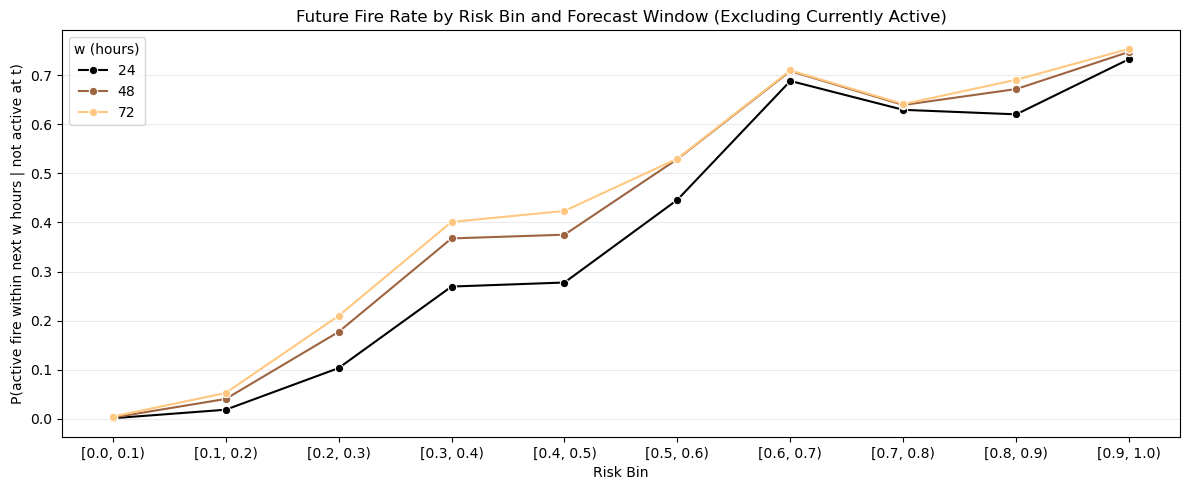

In [142]:
# Plot
plt.figure(figsize = (12, 5))
sns.lineplot(
    data = proportions_inactive,
    x = 'risk_bin',
    y = 'rate',
    hue = 'horizon_h',
    marker = 'o',
    palette = 'copper'
)
plt.xlabel('Risk Bin')
plt.ylabel('P(active fire within next w hours | not active at t)')
plt.title('Future Fire Rate by Risk Bin and Forecast Window (Excluding Currently Active)')
plt.grid(axis = 'y', alpha = 0.25)
plt.legend(title = 'w (hours)')
plt.tight_layout()
plt.show()

## TESTING

In [261]:
k = 2

risk_power = risk.copy()
risk_power['base_risk'] = risk_power['risk'] * (np.minimum(100, risk_power['dist_fire']) + 1)
risk_power['risk'] = risk_power['base_risk'] * (1 / (1 + (risk_power['dist_fire']/k)))

# Mark currently active fires
fire_now = fire.copy()
fire_now['active_now'] = 1

# Exclude currently active cell-hours
risk_power_inactive = risk_power.merge(fire_now, on = ['h3_id', 'hour_bin'], how = 'left')
risk_power_inactive = risk_power_inactive[risk_power_inactive['active_now'].fillna(0) == 0].drop(columns = ['active_now']).copy()


In [262]:
# Compute tables
proportions_power = get_fire_proportions(risk_power_inactive, fire)
proportions_power_table = get_pivot_table(proportions_power)
print(proportions_power_table)

horizon_h         24        48        72
risk_bin                                
[0.0, 0.1)  0.000946  0.002111  0.004134
[0.1, 0.2)  0.002746  0.006919  0.010248
[0.2, 0.3)  0.020953  0.044744  0.058180
[0.3, 0.4)  0.104373  0.178910  0.206721
[0.4, 0.5)  0.211236  0.305198  0.339480
[0.5, 0.6)  0.301849  0.375139  0.416574
[0.6, 0.7)  0.460310  0.556166  0.583874
[0.7, 0.8)  0.629446  0.639352  0.641153
[0.8, 0.9)  0.620275  0.671821  0.690722
[0.9, 1.0)  0.732919  0.747600  0.753811


/var/folders/w1/ftfbr5xs18x1zlwfq09kkxgm0000gn/T/ipykernel_62175/78696389.py:64: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  return results.pivot_table(


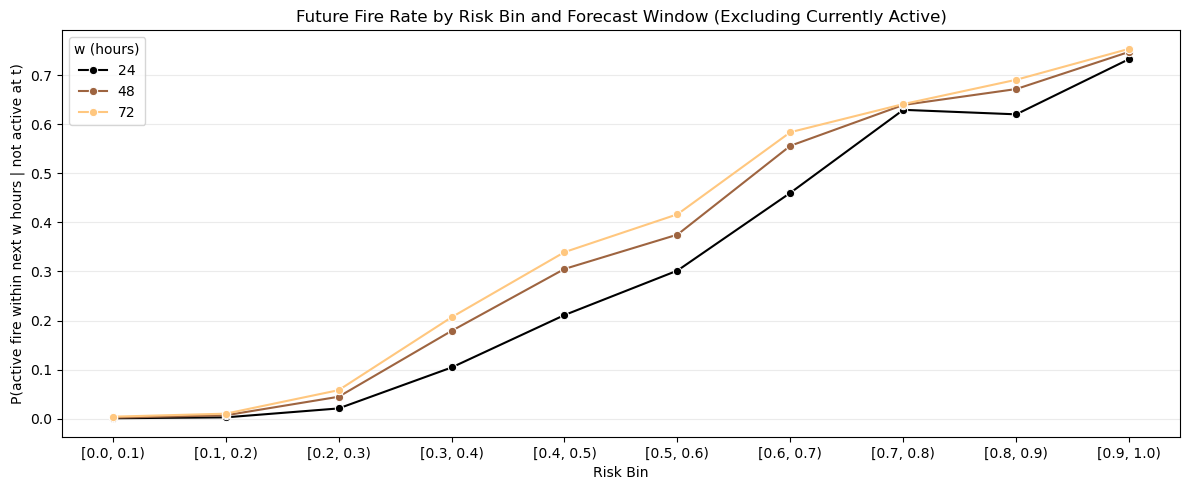

In [263]:
# Plot
plt.figure(figsize = (12, 5))
sns.lineplot(
    data = proportions_power,
    x = 'risk_bin',
    y = 'rate',
    hue = 'horizon_h',
    marker = 'o',
    palette = 'copper'
)
plt.xlabel('Risk Bin')
plt.ylabel('P(active fire within next w hours | not active at t)')
plt.title('Future Fire Rate by Risk Bin and Forecast Window (Excluding Currently Active)')
plt.grid(axis = 'y', alpha = 0.25)
plt.legend(title = 'w (hours)')
plt.tight_layout()
plt.show()